In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [25]:
word_index = imdb.get_word_index()
reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
def decode_review(review):
    words = []
    for id in review:
        if id >= 3:
            word = reverse_word_index.get(
                id - 3,
                "?"
            )
            words.append(word)
    return " ".join(words)

In [27]:
print("Review as IDs:")
print(X_train[0])

print("\nReview as Actual Text:")
print(decode_review(X_train[0]))

print("\nActual Sentiment:")

if y_train[0] == 1:
    print("Positive")
else:
    print("Negative")

Review as IDs:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  144   30 5535   18   51   36   28  224   92  

In [4]:
print("First 10 labels:")
print(y_train[:10])

First 10 labels:
[1 0 0 1 0 0 1 0 1 0]


In [5]:
print("First review length:", len(X_train[0]))
print("Second review length:", len(X_train[1]))
print("Third review length:", len(X_train[2]))

First review length: 218
Second review length: 189
Third review length: 141


In [6]:
max_length = 200

In [7]:
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


In [30]:
model = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=128
    ),

    SimpleRNN(
        128,
        activation="tanh"
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,217 (5.04 MB)

 Trainable params: 1,321,217 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

In [34]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping
    ]

)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 141ms/step - accuracy: 0.4910 - loss: 0.7095 - val_accuracy: 0.5062 - val_loss: 0.7001
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.5012 - loss: 0.6990 - val_accuracy: 0.4936 - val_loss: 0.7003
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 139ms/step - accuracy: 0.5023 - loss: 0.6969 - val_accuracy: 0.5016 - val_loss: 0.6935
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.5046 - loss: 0.6940 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.5040 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.4952 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.5018 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933


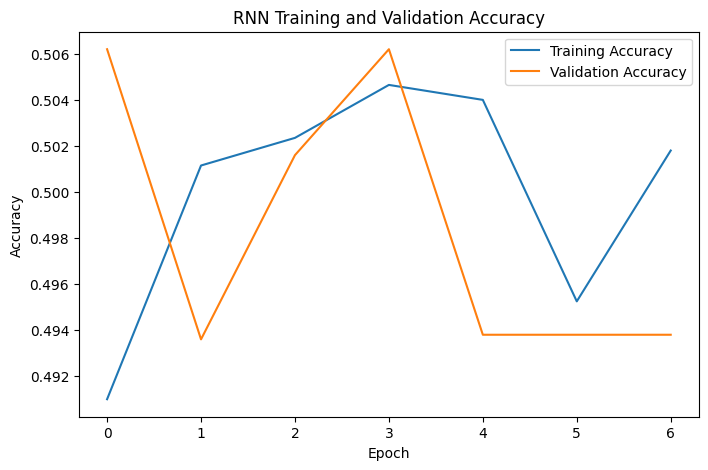

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("RNN Training and Validation Accuracy")

plt.legend()

plt.show()

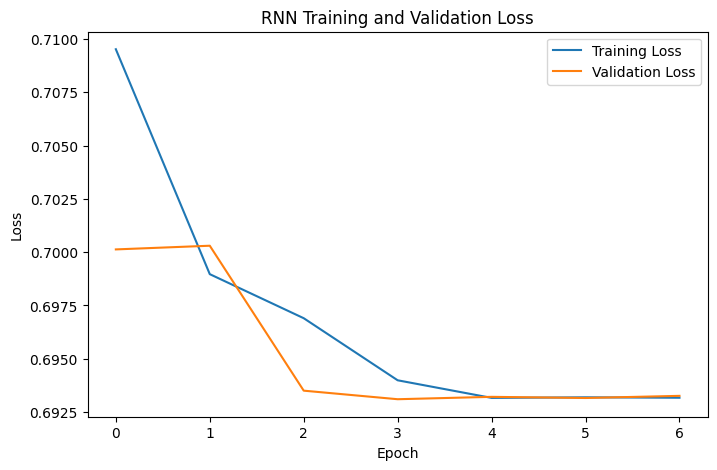

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("RNN Training and Validation Loss")

plt.legend()

plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5000 - loss: 0.6932
Test Loss: 0.6931586861610413
Test Accuracy: 0.5


In [38]:
y_probability = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step


In [39]:
y_pred = (y_probability >= 0.5).astype(int)

In [40]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67     12500
    Positive       0.00      0.00      0.00     12500

    accuracy                           0.50     25000
   macro avg       0.25      0.50      0.33     25000
weighted avg       0.25      0.50      0.33     25000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

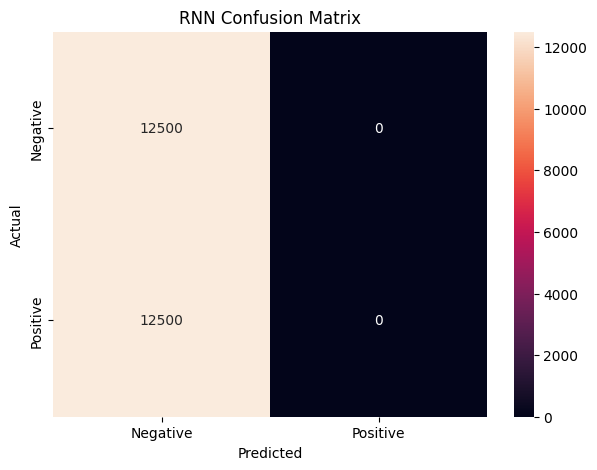

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=[
        "Negative",
        "Positive"
    ],

    yticklabels=[
        "Negative",
        "Positive"
    ]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("RNN Confusion Matrix")

plt.show()